# PCA vs Autoencoder for Image Dimensionality Reduction (MNIST)

## What is dimensionality reduction?
**Dimensionality reduction** is the process of projecting high-dimensional data (here, 28x28 = 784-dimensional images)
into a lower-dimensional space (e.g. 2 or 3 dimensions) while preserving as much of the important structure as possible.
It is useful for visualization, compression, noise reduction, and as a preprocessing step for other models.

## PCA vs Autoencoder
- **PCA (Principal Component Analysis)** is a *linear* method. It finds the directions of maximum variance in the data
  and projects the data onto the top few directions. It requires no training loop, no neural network, and has a
  closed-form solution.
- **Autoencoder** is a *nonlinear* neural-network method. An encoder network compresses the image into a small latent
  vector, and a decoder network reconstructs the image from it. Because of nonlinear activations, it can capture
  curved, complex manifolds that PCA cannot.

## Latent space
The **latent space** is the low-dimensional space in which the compressed representation of each input lives.
A good latent space places similar inputs (e.g. the same digit) close together, which is what we will visualize below.

**Notebook plan:** load MNIST -> visualize samples -> PCA (2D & 3D) -> build & train an Autoencoder (latent_dim=3) ->
extract latent vectors -> visualize latent space -> compare reconstructions -> final comparison.

In [1]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as transforms

from sklearn.decomposition import PCA

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (enables 3D projection)

# Reproducibility & device selection (CPU/GPU)
torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Configuration
BATCH_SIZE = 128
LATENT_DIM = 3              # latent dimension of the autoencoder
EPOCHS = 20                 # training epochs (educational setting)
MAX_TRAIN_SAMPLES = 10000   # training subset used for PCA/training/visualization to keep
                            # runtime practical; set to None to use all 60,000 images

# ToTensor() converts images to float tensors with pixel values in [0, 1]
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# num_workers=0 keeps this notebook Windows-compatible
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Training samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

Training samples: 60000, Test samples: 10000


In [3]:
# Collect a labeled subset of the TRAINING set (used for all PCA / visualization / training).
# We take the first MAX_TRAIN_SAMPLES images for a fast, educational runtime; the test set is
# kept untouched and the training subset is what we fit PCA on and train the autoencoder on.
n = len(train_dataset) if MAX_TRAIN_SAMPLES is None else min(MAX_TRAIN_SAMPLES, len(train_dataset))
images = torch.stack([train_dataset[i][0] for i in range(n)])   # (n, 1, 28, 28) in [0, 1]
labels = torch.tensor([train_dataset[i][1] for i in range(n)])  # (n,)
train_subset = Subset(train_dataset, range(n))

# Loader used for TRAINING the autoencoder: same subset as PCA/visualizations
# (shuffled only for better mini-batch mixing; this does NOT affect extraction order).
subset_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

# Deterministic loader for latent extraction / reconstruction: shuffle=False so the
# order of latents/recons exactly matches `images` and `labels` above.
subset_eval_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Subset images: {images.shape}, labels: {labels.shape}")
print(f"subset_loader batches: {len(subset_loader)}, subset_eval_loader batches: {len(subset_eval_loader)}")

Subset images: torch.Size([10000, 1, 28, 28]), labels: torch.Size([10000])
subset_loader batches: 79, subset_eval_loader batches: 79


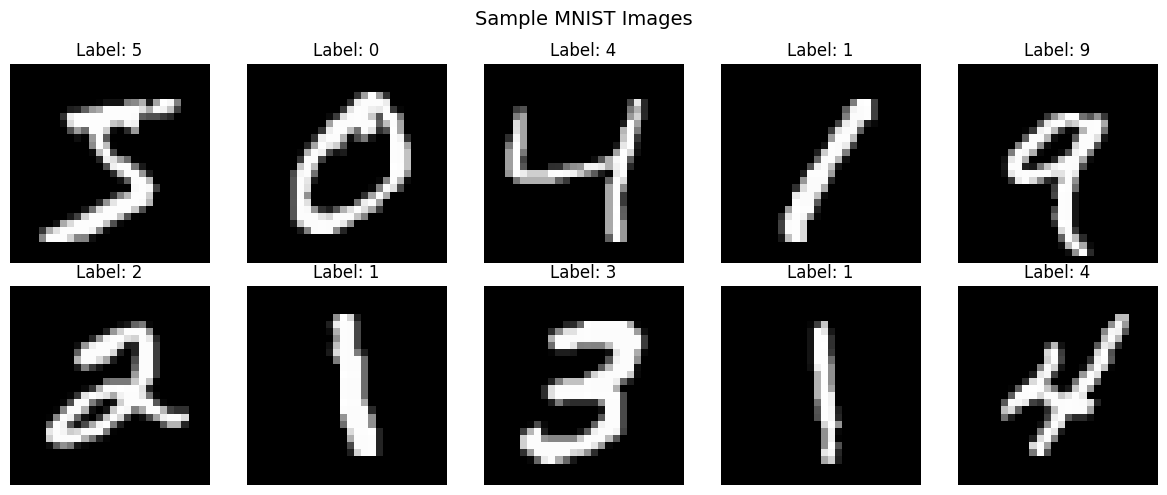

In [4]:
# Visualize 10 sample MNIST images with their labels
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, img, lbl in zip(axes.flat, images[:10], labels[:10]):
    ax.imshow(img.squeeze().numpy(), cmap="gray")
    ax.set_title(f"Label: {lbl.item()}")
    ax.axis("off")
fig.suptitle("Sample MNIST Images", fontsize=14)
plt.tight_layout()
plt.show()

## 2. PCA - Linear Dimensionality Reduction

We flatten each 28x28 image into a 784-dimensional vector and fit scikit-learn's PCA for
2 and 3 components. PCA is fit on the training subset only.

In [5]:
# Flatten images: (n, 1, 28, 28) -> (n, 784)
X = images.view(images.size(0), -1).numpy()
print(f"Flattened data shape: {X.shape}")

# PCA with 2 components
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X)

# PCA with 3 components
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X)

print(f"Explained variance ratio (2 components): {pca_2d.explained_variance_ratio_}")
print(f"Explained variance ratio (3 components): {pca_3d.explained_variance_ratio_}")

Flattened data shape: (10000, 784)
Explained variance ratio (2 components): [0.10199922 0.07215528]
Explained variance ratio (3 components): [0.10199922 0.07215528 0.06110769]


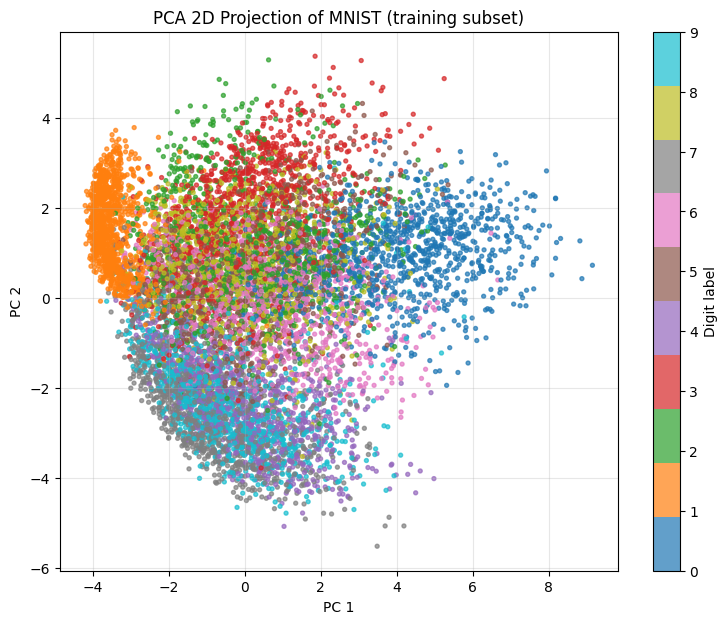

In [6]:
# 2D PCA scatter colored by digit label
plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=labels.numpy(), cmap="tab10", s=8, alpha=0.7)
plt.colorbar(scatter, ticks=range(10), label="Digit label")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("PCA 2D Projection of MNIST (training subset)")
plt.grid(alpha=0.3)
plt.show()

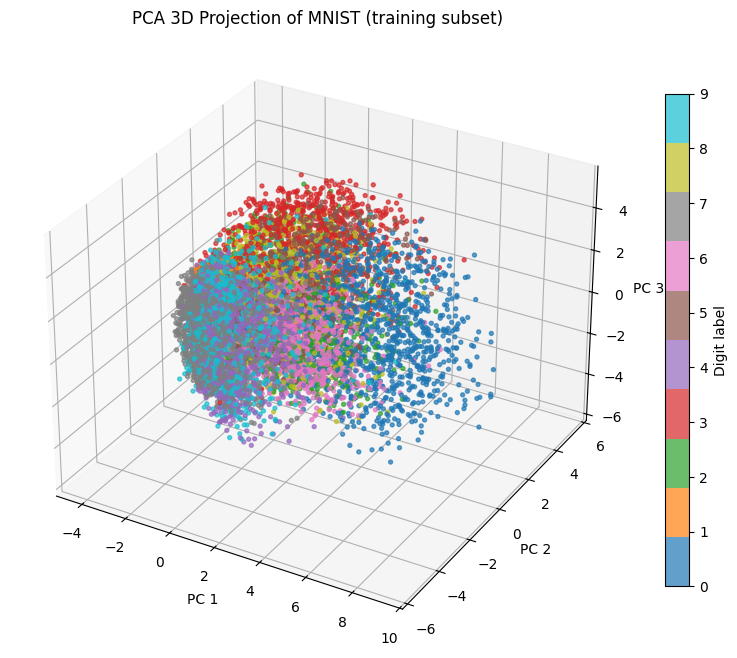

In [7]:
# 3D PCA scatter (matplotlib 3D projection)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
p = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
               c=labels.numpy(), cmap="tab10", s=8, alpha=0.7)
fig.colorbar(p, ticks=range(10), label="Digit label", shrink=0.8)
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_zlabel("PC 3")
ax.set_title("PCA 3D Projection of MNIST (training subset)")
plt.show()

## 3. Autoencoder - Nonlinear Dimensionality Reduction

Architecture:
- **Encoder:** 784 -> 256 -> 64 -> `latent_dim` (ReLU between Linear layers)
- **Decoder:** `latent_dim` -> 64 -> 256 -> 784 (ReLU hidden, **Sigmoid** output to match [0,1] pixels)

We train with `latent_dim = 3` so the latent space can be plotted directly in 3D.

In [8]:
class Autoencoder(nn.Module):
    """Simple fully-connected autoencoder for 28x28 images."""
    def __init__(self, latent_dim=3):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid(),  # outputs in [0, 1] like the input pixels
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

model = Autoencoder(latent_dim=LATENT_DIM).to(device)
print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=3, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


In [9]:
# Training setup: MSE reconstruction loss + Adam optimizer.
# NOTE: we train on `subset_loader` (the same 10,000-image subset used for PCA and
# visualizations), NOT the full 60,000-image train_loader. This keeps the PCA vs
# autoencoder comparison fair and makes the later latent extraction consistent
# with `images`/`labels` and the PCA fit.
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

model.train()
for epoch in range(1, EPOCHS + 1):
    running_loss, seen = 0.0, 0
    for imgs, _ in subset_loader:
        imgs = imgs.view(imgs.size(0), -1).to(device)   # flatten batch to (B, 784)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, imgs)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        seen += imgs.size(0)
    avg_loss = running_loss / seen
    print(f"Epoch [{epoch:2d}/{EPOCHS}] - Average training loss (MSE): {avg_loss:.5f}")

Epoch [ 1/20] - Average training loss (MSE): 0.09297
Epoch [ 2/20] - Average training loss (MSE): 0.06105
Epoch [ 3/20] - Average training loss (MSE): 0.05488
Epoch [ 4/20] - Average training loss (MSE): 0.04979
Epoch [ 5/20] - Average training loss (MSE): 0.04769
Epoch [ 6/20] - Average training loss (MSE): 0.04623
Epoch [ 7/20] - Average training loss (MSE): 0.04497
Epoch [ 8/20] - Average training loss (MSE): 0.04389
Epoch [ 9/20] - Average training loss (MSE): 0.04297
Epoch [10/20] - Average training loss (MSE): 0.04210
Epoch [11/20] - Average training loss (MSE): 0.04144
Epoch [12/20] - Average training loss (MSE): 0.04076
Epoch [13/20] - Average training loss (MSE): 0.04021
Epoch [14/20] - Average training loss (MSE): 0.03968
Epoch [15/20] - Average training loss (MSE): 0.03909
Epoch [16/20] - Average training loss (MSE): 0.03868
Epoch [17/20] - Average training loss (MSE): 0.03830
Epoch [18/20] - Average training loss (MSE): 0.03792
Epoch [19/20] - Average training loss (MSE): 0

## 4. Extract Latent Features

We now pass the **entire selected training subset** (the `MAX_TRAIN_SAMPLES` images defined earlier) through the
trained encoder and collect the latent vectors. We use the training subset (not the test set) for consistency with
PCA, which was also fit on it - this makes the comparison of latent spaces fair.

In [10]:
model.eval()
latent_list, recon_list = [], []
with torch.no_grad():
    for imgs, _ in subset_eval_loader:   # shuffle=False -> order matches images/labels
        flat = imgs.view(imgs.size(0), -1).to(device)
        z = model.encoder(flat)        # latent vectors
        rec = model.decoder(z)         # reconstructions
        latent_list.append(z.cpu())
        recon_list.append(rec.cpu())

latents = torch.cat(latent_list).numpy()             # (n, latent_dim) for the full subset
recons = torch.cat(recon_list).view(-1, 1, 28, 28)   # (n, 1, 28, 28)
assert latents.shape[0] == labels.shape[0] == recons.shape[0], (
    f"Order mismatch: latents={latents.shape[0]}, labels={labels.shape[0]}, recons={recons.shape[0]}")
print(f"Latent vectors: {latents.shape}, Reconstructions: {recons.shape}")
print(f"Consistency check passed: {latents.shape[0]} latents == {labels.shape[0]} labels "
      f"== {recons.shape[0]} reconstructions (same order as the {n}-image subset)")

Latent vectors: (10000, 3), Reconstructions: torch.Size([10000, 1, 28, 28])
Consistency check passed: 10000 latents == 10000 labels == 10000 reconstructions (same order as the 10000-image subset)


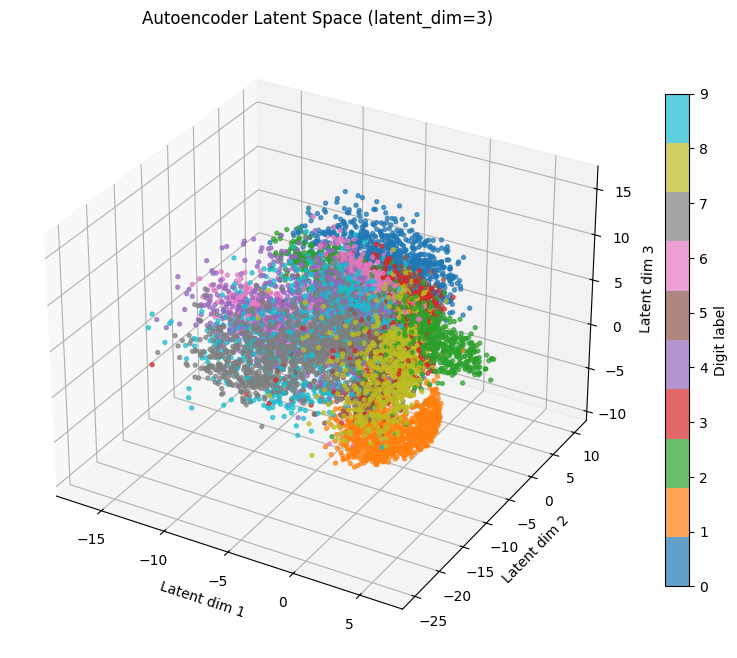

In [11]:
# 3D scatter of the autoencoder latent space, colored by digit label
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
p = ax.scatter(latents[:, 0], latents[:, 1], latents[:, 2],
               c=labels.numpy(), cmap="tab10", s=8, alpha=0.7)
fig.colorbar(p, ticks=range(10), label="Digit label", shrink=0.8)
ax.set_xlabel("Latent dim 1")
ax.set_ylabel("Latent dim 2")
ax.set_zlabel("Latent dim 3")
ax.set_title(f"Autoencoder Latent Space (latent_dim={LATENT_DIM})")
plt.show()

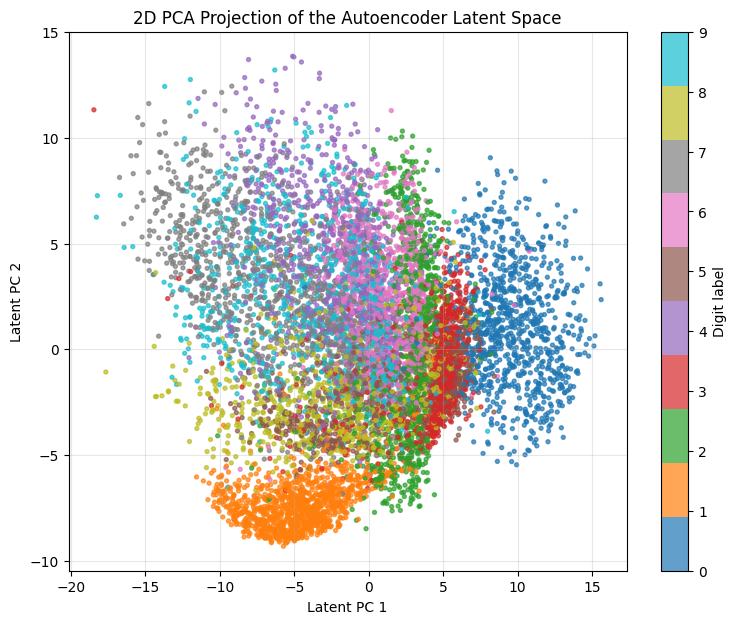

In [12]:
# 2D view of the latent space: PCA(n_components=2) applied to the latent vectors
pca_latent = PCA(n_components=2)
latents_2d = pca_latent.fit_transform(latents)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(latents_2d[:, 0], latents_2d[:, 1], c=labels.numpy(), cmap="tab10", s=8, alpha=0.7)
plt.colorbar(scatter, ticks=range(10), label="Digit label")
plt.xlabel("Latent PC 1")
plt.ylabel("Latent PC 2")
plt.title("2D PCA Projection of the Autoencoder Latent Space")
plt.grid(alpha=0.3)
plt.show()

## 5. Reconstruction Quality

Top row: original images. Bottom row: the autoencoder's reconstructions from the 3-dimensional latent code.

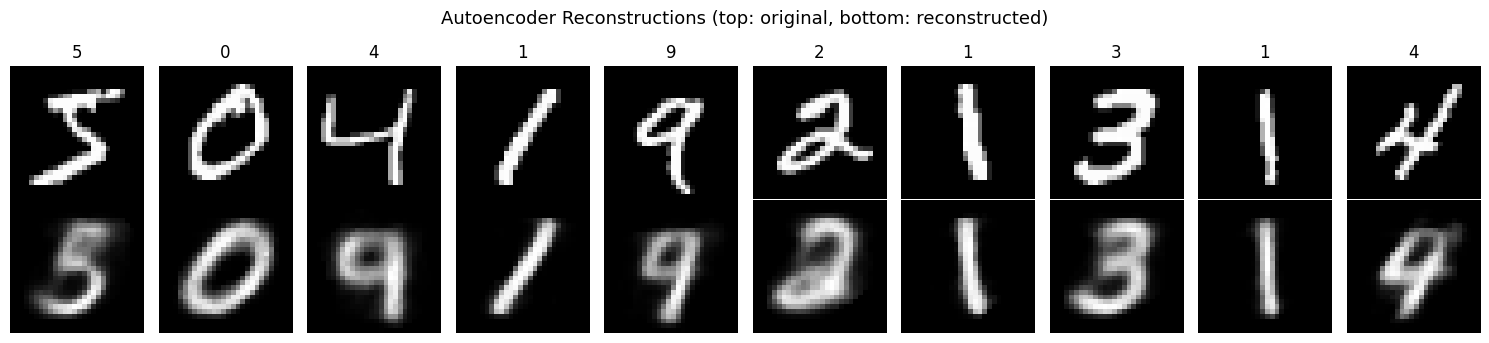

In [13]:
# Reconstruction comparison: originals (top row) vs reconstructions (bottom row)
n_show = 10
fig, axes = plt.subplots(2, n_show, figsize=(15, 3.5))
for i in range(n_show):
    axes[0, i].imshow(images[i].squeeze().numpy(), cmap="gray")
    axes[0, i].set_title(f"{labels[i].item()}")
    axes[0, i].axis("off")
    axes[1, i].imshow(recons[i].squeeze().numpy(), cmap="gray")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("Reconstructed", fontsize=10)
fig.suptitle("Autoencoder Reconstructions (top: original, bottom: reconstructed)", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Final Comparison: PCA vs Autoencoder

| Aspect | PCA | Autoencoder |
|---|---|---|
| Type | Linear dimensionality reduction | Nonlinear dimensionality reduction |
| How it works | Finds the directions of **maximum variance** in the data and projects onto them | A neural network **learns a latent representation** end-to-end by minimizing reconstruction error |
| Neural network | No - closed-form linear algebra | Yes - encoder/decoder trained with gradient descent |
| Complexity captured | Only linear (flat, hyperplanar) structure | Can capture **complex, curved patterns** thanks to nonlinear activations |
| Visualization quality on MNIST | Digits overlap substantially in 2D/3D | Digits form tighter, more separated clusters in the latent space |
| Cost | Very cheap, deterministic | Requires training time and hyperparameter choices |

**Takeaway:** PCA is a fast, interpretable linear baseline that explains variance but cannot model nonlinear
manifolds. The autoencoder, even with only a 3-dimensional latent space, learns a nonlinear latent representation
that groups similar digits together and produces recognizable reconstructions - demonstrating why learned
representations are powerful for complex data like images.

*(Educational note: a subset of 10,000 training images and a compact MLP autoencoder were used so the notebook
runs quickly on CPU; scaling up data, epochs, or the latent dimension improves results.)*